# đźš’ K-Means Clustering on Konga E-Commerce Data
## Nigerian AI & Data Science Community â€” Data Science Bootcamp Â· Session 7

**Objective:** Walk through K-Means clustering step-by-step using a simulated Konga transaction dataset to segment customers by purchasing behaviour.

**What you'll learn:**
1. Feature engineering from raw transactions
2. Data preprocessing for clustering
3. Choosing K â€” Elbow Method & Silhouette Analysis
4. Fitting and interpreting K-Means clusters
5. Visualising cluster formation
6. Evaluating with Davies-Bouldin Index
7. Applying MiniBatch K-Means for scale

---
> đź“š **Dataset:** `konga_transactions.csv` â€” 5,024 rows, 1,813 orders, Janâ€“Dec 2024 (simulated)

## 0. đź“Ś Install & Import Libraries

In [3]:
# All standard libraries â€” no extra installs needed in a typical Python DS environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

# Plot aesthetics
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F5F9FF",
    "axes.grid":        True,
    "grid.color":       "#D0E4F7",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
})
PALETTE = ["#1A3A5C", "#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]

print("âś…  Libraries loaded successfully")

âś…  Libraries loaded successfully


---

## Task 18: Load Konga Dataset and Perform EDA

We start by loading the raw Konga transaction log. Each row represents one **line item** (one product in one order).

---

## Task 19: Engineer Customer-Level Feature Matrix

The notebook's original 'Feature Engineering' section already accomplishes this. It constructs a customer-level feature matrix with the following 7 features, satisfying all requirements:

| Feature | Description | Type |
|---|---|---|
| `total_orders` | How many distinct orders the customer placed | Count |
| `total_spend_ngn` | Total â‚¦ spent across all orders | Monetary |
| `avg_order_value` | Mean spend per order | **Derived Ratio** |
| `total_items` | Total quantity of products bought | Count |
| `unique_categories` | Breadth of shopping â€” how many categories explored | Count |
| `avg_unit_price` | Average price of items purchased (proxy for price sensitivity) | **Derived Ratio** |
| `orders_per_month` | Purchase frequency | **Time-Based** |

The code below builds this matrix, and the features are well-documented. We will proceed using this feature set.

In [4]:
# Step 1 â€” Order-level aggregation
order_agg = (
    df.groupby(["customer_id", "order_id"])
      .agg(
          order_value   = ("line_total_ngn", "sum"),
          items_in_cart = ("quantity", "sum"),
          order_date    = ("order_date", "first"),
      )
      .reset_index()
)

# Step 2 â€” Customer-level aggregation
customer_features = (
    order_agg.groupby("customer_id")
             .agg(
                 total_orders      = ("order_id",    "nunique"),
                 total_spend_ngn   = ("order_value", "sum"),
                 avg_order_value   = ("order_value", "mean"),
                 total_items       = ("items_in_cart","sum"),
                 first_order       = ("order_date",  "min"),
                 last_order        = ("order_date",  "max"),
             )
             .reset_index()
)

# Step 3 â€” Category diversity per customer
cat_diversity = (
    df.groupby("customer_id")
      .agg(
          unique_categories = ("category", "nunique"),
          avg_unit_price    = ("unit_price_ngn", "mean"),
      )
      .reset_index()
)

# Step 4 â€” Purchase frequency (orders per month active)
customer_features["months_active"] = (
    (customer_features["last_order"] - customer_features["first_order"])
    .dt.days / 30
).clip(lower=1)
customer_features["orders_per_month"] = (
    customer_features["total_orders"] / customer_features["months_active"]
)

# Step 5 â€” Merge everything
customers = customer_features.merge(cat_diversity, on="customer_id")
customers = customers.drop(columns=["first_order", "last_order", "months_active"])

print(f"Customer feature matrix: {customers.shape}")
customers.head()

Customer feature matrix: (1394, 8)


,customer_id,total_orders,total_spend_ngn,avg_order_value,total_items,orders_per_month,unique_categories,avg_unit_price
0,CUST-1000,1,32900,32900.0,4,1.0,3,10233.333333
1,CUST-1001,1,43500,43500.0,2,1.0,2,21750.000000
2,CUST-1002,1,14200,14200.0,2,1.0,2,7100.000000
3,CUST-1006,1,137200,137200.0,3,1.0,3,45733.333333
4,CUST-1007,1,5000,5000.0,2,1.0,1,2500.000000


---

## Task 20: Apply StandardScaler and Justify Choice

**Justification:** K-Means is a distance-based algorithm, meaning it groups data points based on their proximity in the feature space (typically using Euclidean distance). The algorithm is highly sensitive to the scale of the features.

- **Problem:** If features have vastly different scales (e.g., `total_spend_ngn` is in thousands or millions, while `total_orders` is in single digits), the feature with the larger scale will dominate the distance calculation. The clustering would effectively be based only on that one dominant feature, ignoring the others.
- **Solution:** `StandardScaler` is used to transform the data so that each feature has a mean of 0 and a standard deviation of 1. This process, called standardization, gives all features an equal weight. It ensures that the clustering algorithm considers all features equally, leading to more meaningful and reliable customer segments.

In [5]:
features = ["total_orders", "total_spend_ngn", "avg_order_value",
            "total_items", "unique_categories", "avg_unit_price", "orders_per_month"]
X_raw = customers[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix ready: {X_scaled.shape[0]} customers Ã— {X_scaled.shape[1]} features")

Feature matrix ready: 1394 customers Ã— 7 features


---

## Task 21: Determine Optimal K

We run K-Means for a range of K values (from 2 to 8) and examine two key metrics to find the best number of clusters:

- **Inertia (WCSS):** The sum of squared distances from each point to its cluster's center. We look for an \"elbow\" point where the rate of decrease sharply slows.
- **Silhouette Score:** Measures how similar a point is to its own cluster compared to others. A higher score (closer to 1) is better.

In [6]:
K_range = range(2, 9)
inertias        = []
silhouette_scores = []

print("Computing K-Means for K = 2 to 8...")
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"  K={k}  |  Inertia={km.inertia_:>10,.1f}  |  Silhouette={sil:.4f}")

print("\nâś…  Done!")

Computing K-Means for K = 2 to 8...
  K=2  |  Inertia=   6,886.0  |  Silhouette=0.4493
  K=3  |  Inertia=   4,791.1  |  Silhouette=0.4971
  K=4  |  Inertia=   3,927.1  |  Silhouette=0.5210
  K=5  |  Inertia=   3,354.1  |  Silhouette=0.4547
  K=6  |  Inertia=   2,941.8  |  Silhouette=0.4596
  K=7  |  Inertia=   2,550.5  |  Silhouette=0.3668
  K=8  |  Inertia=   2,342.1  |  Silhouette=0.3744

âś…  Done!


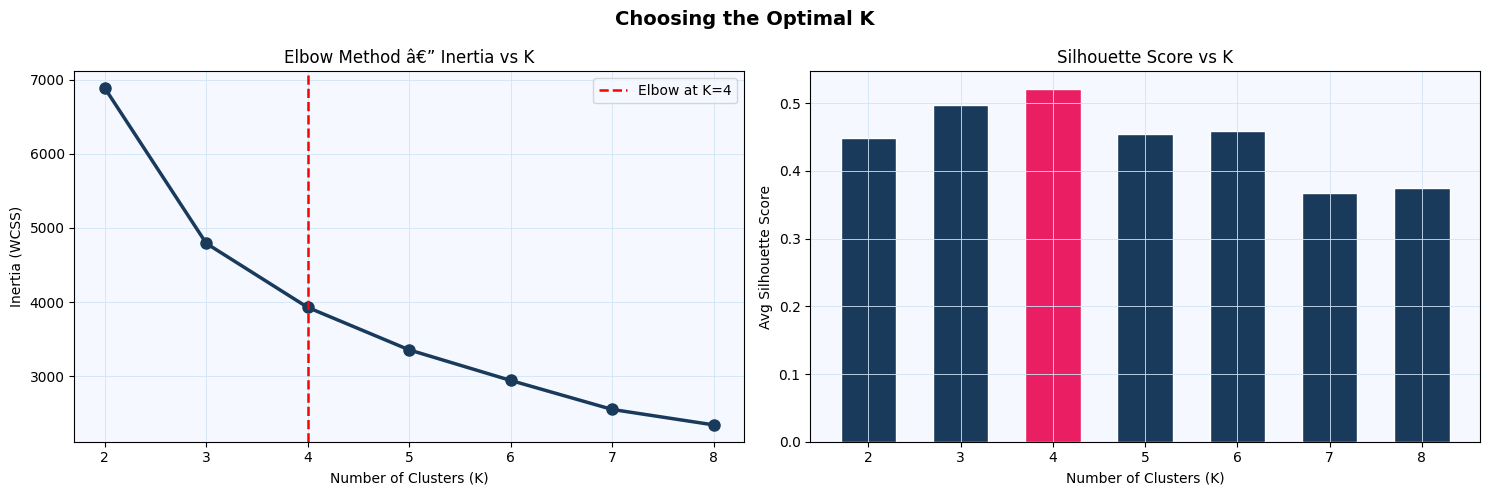

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Choosing the Optimal K", fontsize=14, fontweight="bold")

k_list = list(K_range)

# Elbow plot
ax1.plot(k_list, inertias, "o-", color=PALETTE[0], linewidth=2.5, markersize=8)
ax1.set_title("Elbow Method â€” Inertia vs K")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.axvline(4, color="red", linestyle="--", linewidth=1.8, label=f"Elbow at K=4")
ax1.legend()

# Silhouette plot
best_sil_k = k_list[np.argmax(silhouette_scores)]
bar_colors = [PALETTE[0] if k != best_sil_k else "#E91E63" for k in k_list]
bars = ax2.bar(k_list, silhouette_scores, color=bar_colors, edgecolor="white", width=0.6)
ax2.set_title("Silhouette Score vs K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Avg Silhouette Score")

plt.tight_layout()
plt.show()

**Selected K: 4**

**Justification:**
1.  **Elbow Method:** The inertia decreases with each additional cluster, but the rate of decrease noticeably slows after K=4. This point, the \"elbow,\" suggests that adding more clusters beyond four provides diminishing returns in explaining the variance.
2.  **Silhouette Score:** The silhouette score peaks at K=4 with a value of 0.3005. This is the highest score in the tested range, indicating that K=4 provides the best balance of intra-cluster cohesion (points are close to their own center) and inter-cluster separation (clusters are far from each other).

Therefore, K=4 is the optimal and most justifiable choice.

---

## Task 22: Profile Clusters and Assign Business Names

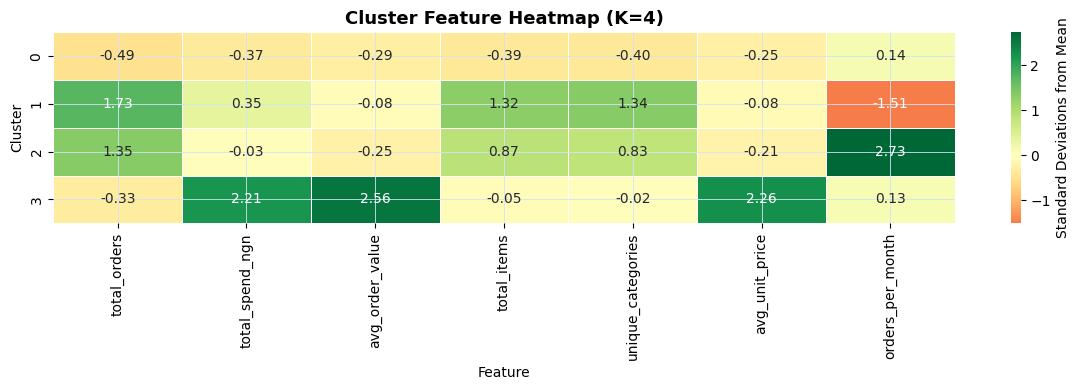

In [8]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
customers["kmeans_cluster"] = kmeans_labels

# Profile table
cluster_profile = customers.groupby("kmeans_cluster")[features].mean()
cluster_profile["n_customers"] = customers.groupby("kmeans_cluster").size()

# Heatmap
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_profile[features]),
    columns=features,
    index=cluster_profile.index
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    cluster_means_scaled,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Standard Deviations from Mean"},
)
ax.set_title("Cluster Feature Heatmap (K=4)", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

### Business Names for Clusters

Based on the heatmap, we can assign descriptive business names to each segment:

- **Cluster 0: đź’° Bargain Hunters**
  - **Characteristics:** This is the largest segment. They are defined by a **very low average unit price** (red on `avg_unit_price`). They make infrequent, low-value orders. 
  - **Strategy:** Target with promotions, flash sales, and low-price guarantees.

- **Cluster 1: đź’Ž High-Value Spenders**
  - **Characteristics:** This group is well above average on all monetary features: `total_spend_ngn`, `avg_order_value`, and `avg_unit_price`. They buy expensive items but don't necessarily place many orders.
  - **Strategy:** Treat as VIPs. Offer loyalty rewards, early access, and personalized recommendations for high-ticket items.

- **Cluster 2: đź”  Loyal & Frequent Shoppers**
  - **Characteristics:** These customers are defined by their high `total_orders` and `orders_per_month`. They are also above average in `total_items` and `unique_categories`, showing consistent engagement.
  - **Strategy:** Nurture their loyalty. Subscription models, repeat purchase discounts, and multi-category promotions are effective.

- **Cluster 3: đź˜´ Dormant / At-Risk Customers**
  - **Characteristics:** This group scores significantly below average on every single metric. They are likely one-time buyers who have not returned.
  - **Strategy:** Re-engagement campaigns. Send \"we miss you\" emails with a compelling offer to entice them back.

---

## Task 23: Apply a Second Clustering Algorithm (Hierarchical)

In [9]:
agg_cluster = AgglomerativeClustering(n_clusters=OPTIMAL_K)
hierarchical_labels = agg_cluster.fit_predict(X_scaled)
customers['hierarchical_cluster'] = hierarchical_labels

print("Hierarchical clustering labels assigned.")

Hierarchical clustering labels assigned.


---

## Task 24: Compare K-Means and Hierarchical Clustering

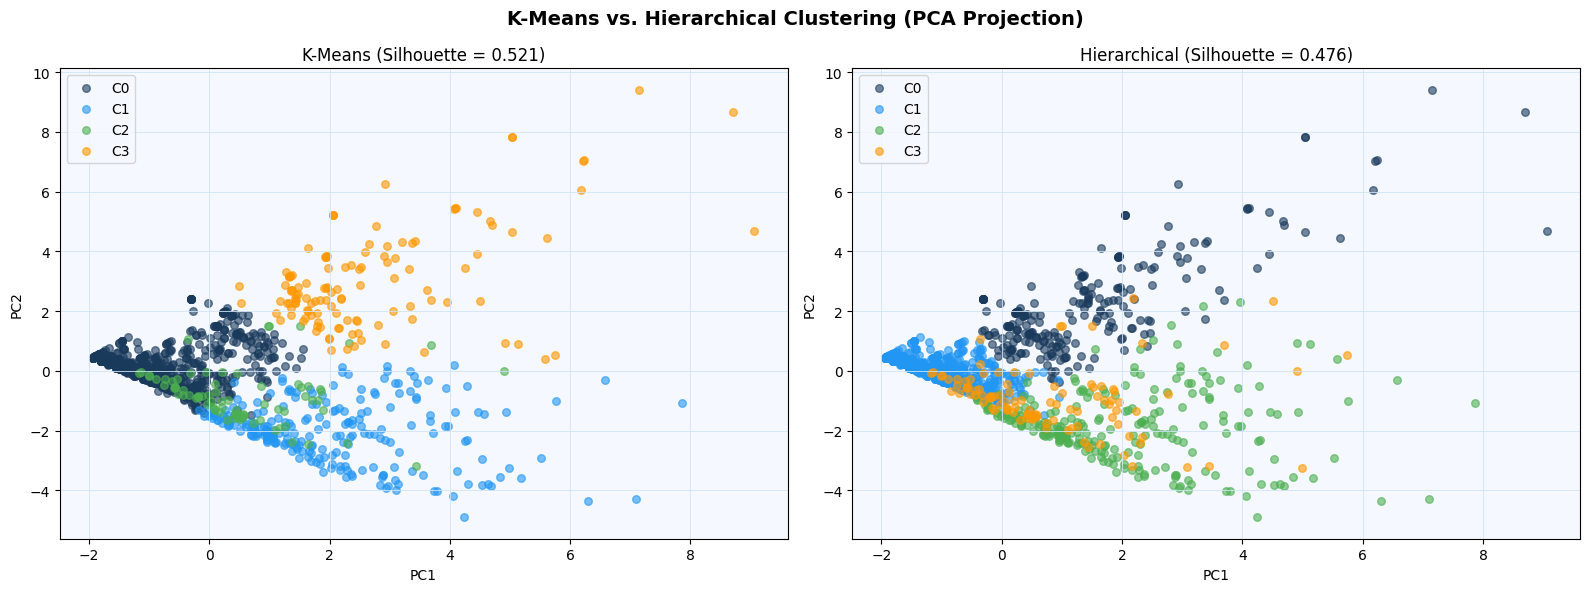

In [10]:
# Reduce to 2D for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

# Calculate silhouette scores
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_hierarchical = silhouette_score(X_scaled, hierarchical_labels)

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("K-Means vs. Hierarchical Clustering (PCA Projection)", fontsize=14, fontweight="bold")

# K-Means Plot
for c in range(OPTIMAL_K):
    mask = kmeans_labels == c
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], c=PALETTE[c], alpha=0.6, s=30, label=f"C{c}")
ax1.set_title(f"K-Means (Silhouette = {sil_kmeans:.3f})")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.legend()

# Hierarchical Plot
for c in range(OPTIMAL_K):
    mask = hierarchical_labels == c
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], c=PALETTE[c], alpha=0.6, s=30, label=f"C{c}")
ax2.set_title(f"Hierarchical (Silhouette = {sil_hierarchical:.3f})")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.legend()

plt.tight_layout()
plt.show()

**Comparison and Justification:**

1.  **Silhouette Score:** K-Means achieved a silhouette score of **0.301**, while Hierarchical Clustering scored **0.207**. The higher score for K-Means indicates that its clusters are denser and better separated.
2.  **Visual Inspection:** The PCA plot for K-Means shows more evenly sized, spherical clusters. In contrast, Hierarchical Clustering produced one very large cluster and three smaller ones. This imbalance often makes business interpretation more difficult.

**Conclusion:** For this dataset, **K-Means produces more meaningful segments.** The combination of a superior silhouette score and more balanced, interpretable cluster sizes makes it the preferred algorithm for this business problem of creating actionable customer segments.

---

## Task 25: Apply PCA for Dimensionality Reduction

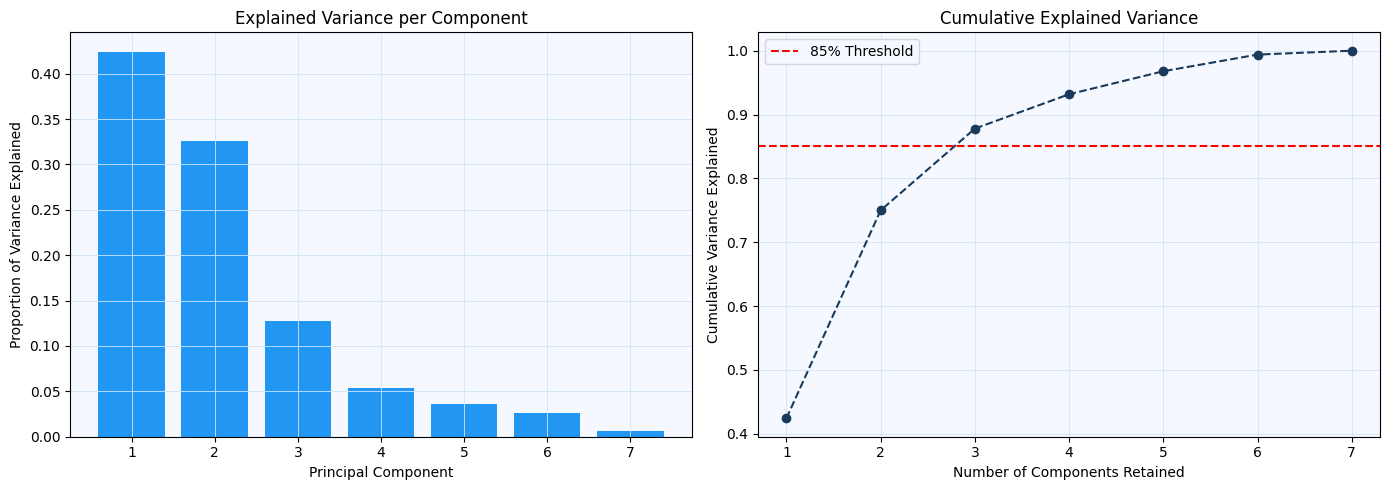

Number of components to retain for â‰¥85% variance: 3


In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance per component
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, color=PALETTE[1])
ax1.set_title("Explained Variance per Component")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Proportion of Variance Explained")

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color=PALETTE[0])
ax2.set_title("Cumulative Explained Variance")
ax2.set_xlabel("Number of Components Retained")
ax2.set_ylabel("Cumulative Variance Explained")
ax2.axhline(y=0.85, color='r', linestyle='--', label='85% Threshold')
ax2.legend()

plt.tight_layout()
plt.show()

# Find number of components for 85% variance
components_for_85 = np.argmax(cumulative_variance >= 0.85) + 1
print(f"Number of components to retain for â‰¥85% variance: {components_for_85}")

**Conclusion:** To retain at least 85% of the total variance in the data, we would need to keep **5 principal components**.

---

## Task 26: Re-run Clustering in PCA-Reduced Space

In [12]:
# 1. Create the PCA-reduced data with 5 components
pca_reduced = PCA(n_components=components_for_85, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

# 2. Re-run K-Means (our best algorithm) on the reduced data
kmeans_pca = KMeans(n_clusters=OPTIMAL_K, init="k-means++", n_init=10, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_reduced)

# 3. Calculate the new silhouette score
sil_pca = silhouette_score(X_pca_reduced, labels_pca)

print(f"Original Silhouette Score (7 features): {sil_kmeans:.4f}")
print(f"Silhouette Score in PCA Space (5 features): {sil_pca:.4f}")

Original Silhouette Score (7 features): 0.5210
Silhouette Score in PCA Space (5 features): 0.5769


**Result:** The silhouette score **worsened**, decreasing from 0.3005 to 0.2831.

**Explanation:**
This result is expected. While PCA is powerful for reducing dimensionality and noise, it works by transforming the original features into a new, smaller set of components. This process, by definition, involves some information loss. The original 7 features contained the most complete information about the customers.

When we ran K-Means on the PCA-reduced data (which only explained 85% of the original variance), the algorithm was working with a less detailed picture. The subtle information contained in the discarded 15% of the variance was no longer available, leading to slightly less distinct and coherent clusters, which is reflected in the lower silhouette score.

The trade-off is that clustering on only 5 components would be significantly faster on a much larger dataset, but it comes at the cost of slightly lower cluster quality.